In [24]:
# Hemora_Thalassemia_Hybrid_Custom_YOLO_ResNet.ipynb #

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
from google.colab import files
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# ==========================================
# 1. DRIVE MOUNT & CONFIGURATION
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# Paths to YOUR trained models
RESNET_MODEL_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/ResNet50 Model/best_thalassemia_res_model.keras'
YOLO_MODEL_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run3/weights/best.pt'
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/Hybrid_Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)




Step 1: Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# ==========================================
# 2. LOAD YOUR MODELS
# ==========================================
print("\nStep 2: Loading YOUR Trained Hybrid Components...")

try:
    # Load YOUR trained YOLOv8 Classification model
    yolo_cls = YOLO(YOLO_MODEL_PATH)
    print("✅ YOUR Trained YOLOv8 Classification Model loaded.")

    # Load YOUR trained ResNet50V2 Classification model
    resnet_cls = load_model(RESNET_MODEL_PATH)
    print("✅ YOUR Trained ResNet50V2 Classification Model loaded.")
except Exception as e:
    print(f"❌ Error: {e}. Check your model paths in Drive.")


Step 2: Loading YOUR Trained Hybrid Components...
✅ YOUR Trained YOLOv8 Classification Model loaded.
✅ YOUR Trained ResNet50V2 Classification Model loaded.


Saving c0222234-800px-wm.jpg to c0222234-800px-wm.jpg

Processing Full Smear: c0222234-800px-wm.jpg...
Segmented 90 potential cells. Starting Hybrid AI Consensus...


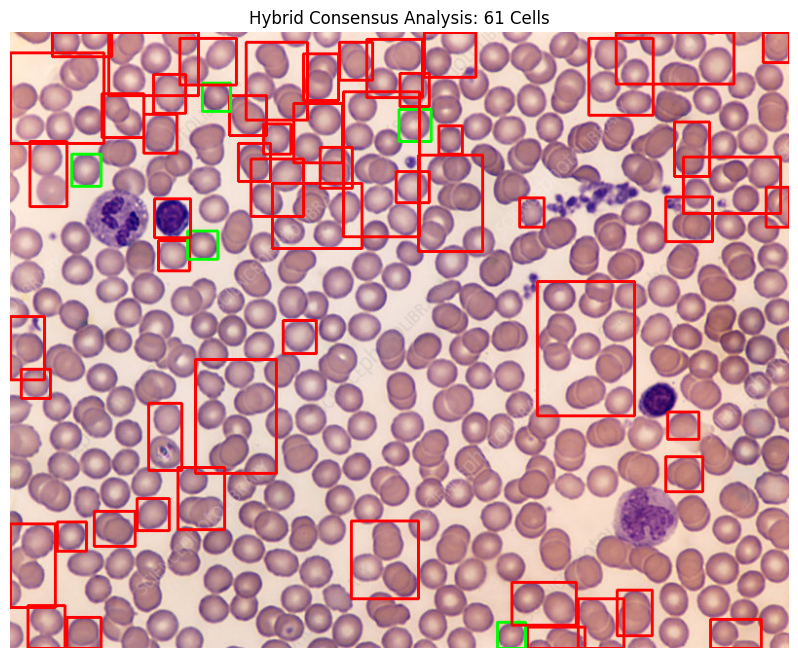

BETA-THALASSEMIA (MINOR) HYBRID AI REPORT
Models Used:          Trained YOLOv8-Cls + Trained ResNet50V2
Total RBCs Analyzed:  61
Abnormal RBCs (Red):  56
Abnormality Ratio:    91.80%

>>> RESULT: POSITIVE indicators for Thalassemia Minor.
>>> RECOMMENDATION: Correlate with CBC numerical data.


In [27]:

# ==========================================
# 3. HYBRID CONSENSUS PIPELINE
# ==========================================
def process_full_smear_hybrid(image_path):
    print(f"\nProcessing Full Smear: {image_path}...")
    original_img = cv2.imread(image_path)
    if original_img is None: return
    output_img = original_img.copy()

    # PHASE 1: OPENCV SEGMENTATION (Since YOLO-Cls has no boxes)
    # This separates individual RBCs for morphology analysis
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    thal_count = 0
    total_cells = 0

    print(f"Segmented {len(contours)} potential cells. Starting Hybrid AI Consensus...")

    # PHASE 2: DUAL-MODEL CONSENSUS
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if cv2.contourArea(cnt) < 400 or cv2.contourArea(cnt) > 7000: continue

        cell_crop = original_img[y:y+h, x:x+w]
        if cell_crop.size == 0: continue
        total_cells += 1

        # A. ResNet Prediction
        res_img = cv2.resize(cv2.cvtColor(cell_crop, cv2.COLOR_BGR2RGB), (224, 224))
        res_img = img_to_array(res_img) / 255.0
        res_pred = resnet_cls.predict(np.expand_dims(res_img, axis=0), verbose=0)[0][0]

        # B. YOUR YOLO Prediction
        yolo_results = yolo_cls(cell_crop, verbose=False)[0]
        # Get the probability for the Thalassemia class (assuming index 1)
        yolo_pred = yolo_results.probs.data[1].item() if len(yolo_results.probs.data) > 1 else 0

        # HYBRID DECISION: Combine both models (Average Score)
        # This increases diagnostic reliability
        hybrid_score = (res_pred + yolo_pred) / 2

        if hybrid_score > 0.5:
            color = (0, 0, 255) # Red for Thalassemia features
            thal_count += 1
        else:
            color = (0, 255, 0) # Green for Normal morphology

        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

    # Visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Hybrid Consensus Analysis: {total_cells} Cells")
    plt.show()

    # PHASE 3: CLINICAL REPORT
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) HYBRID AI REPORT")
    print("="*50)
    print(f"Models Used:          Trained YOLOv8-Cls + Trained ResNet50V2")
    print(f"Total RBCs Analyzed:  {total_cells}")
    print(f"Abnormal RBCs (Red):  {thal_count}")

    if total_cells > 0:
        ratio = (thal_count / total_cells) * 100
        print(f"Abnormality Ratio:    {ratio:.2f}%")
        if ratio > 5.0:
            print("\n>>> RESULT: POSITIVE indicators for Thalassemia Minor.")
            print(">>> RECOMMENDATION: Correlate with CBC numerical data.")
        else:
            print("\n>>> RESULT: NEGATIVE - Smear appears normal.")
    print("="*50)

# --- RUN ---
uploaded = files.upload()
if uploaded:
    img_name = list(uploaded.keys())[0]
    process_full_smear_hybrid(img_name)